In [1]:
import importlib.util
import sys
import os

# Path to the actual Python file
module_path = os.path.abspath('../datasets/har_dataset.py')

# Module name and loader
spec = importlib.util.spec_from_file_location("har_dataset", module_path)
har_dataset = importlib.util.module_from_spec(spec)
spec.loader.exec_module(har_dataset)

# Use the class
HARDataset = har_dataset.HARDataset


In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [3]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


In [4]:

trainset = HARDataset(root='./data', train=True)
testset = HARDataset(root='./data', train=False)

print(f"[INFO] Loaded dataset 'HAR' with {len(trainset)} training samples and {len(testset)} testing samples.")


[INFO] Loaded dataset 'HAR' with 7352 training samples and 2947 testing samples.


In [5]:
num_clients = 5
partitions = {
    "iid":      dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),
}

c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)



=== Partition Statistics for HAR ===

IID Partition:
Total samples: 7352

Per-client distribution:
Client 0: 3333 samples (45.33%)
Client 1: 1375 samples (18.70%)
Client 2: 108 samples (1.47%)
Client 3: 1408 samples (19.15%)
Client 4: 1128 samples (15.34%)
[Debug] Number of classes: 6
[Debug] Number of clients: 5
[Debug] Processing client 0 with 3333 samples
[Debug] Client 0 has 3333 valid targets
[Debug] Client 0 class counts: [1.000e+00 1.068e+03 9.810e+02 1.281e+03 1.000e+00 1.000e+00]
[Debug] Processing client 1 with 1375 samples
[Debug] Client 1 has 1375 valid targets
[Debug] Client 1 class counts: [1.00e+00 1.00e+00 1.00e+00 1.00e+00 1.37e+03 1.00e+00]
[Debug] Processing client 2 with 108 samples
[Debug] Client 2 has 108 valid targets
[Debug] Client 2 class counts: [102.   1.   2.   1.   1.   1.]
[Debug] Processing client 3 with 1408 samples
[Debug] Client 3 has 1408 valid targets
[Debug] Client 3 class counts: [1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.403e+03]
[Debug

c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(partitions[0].dataset.targets)


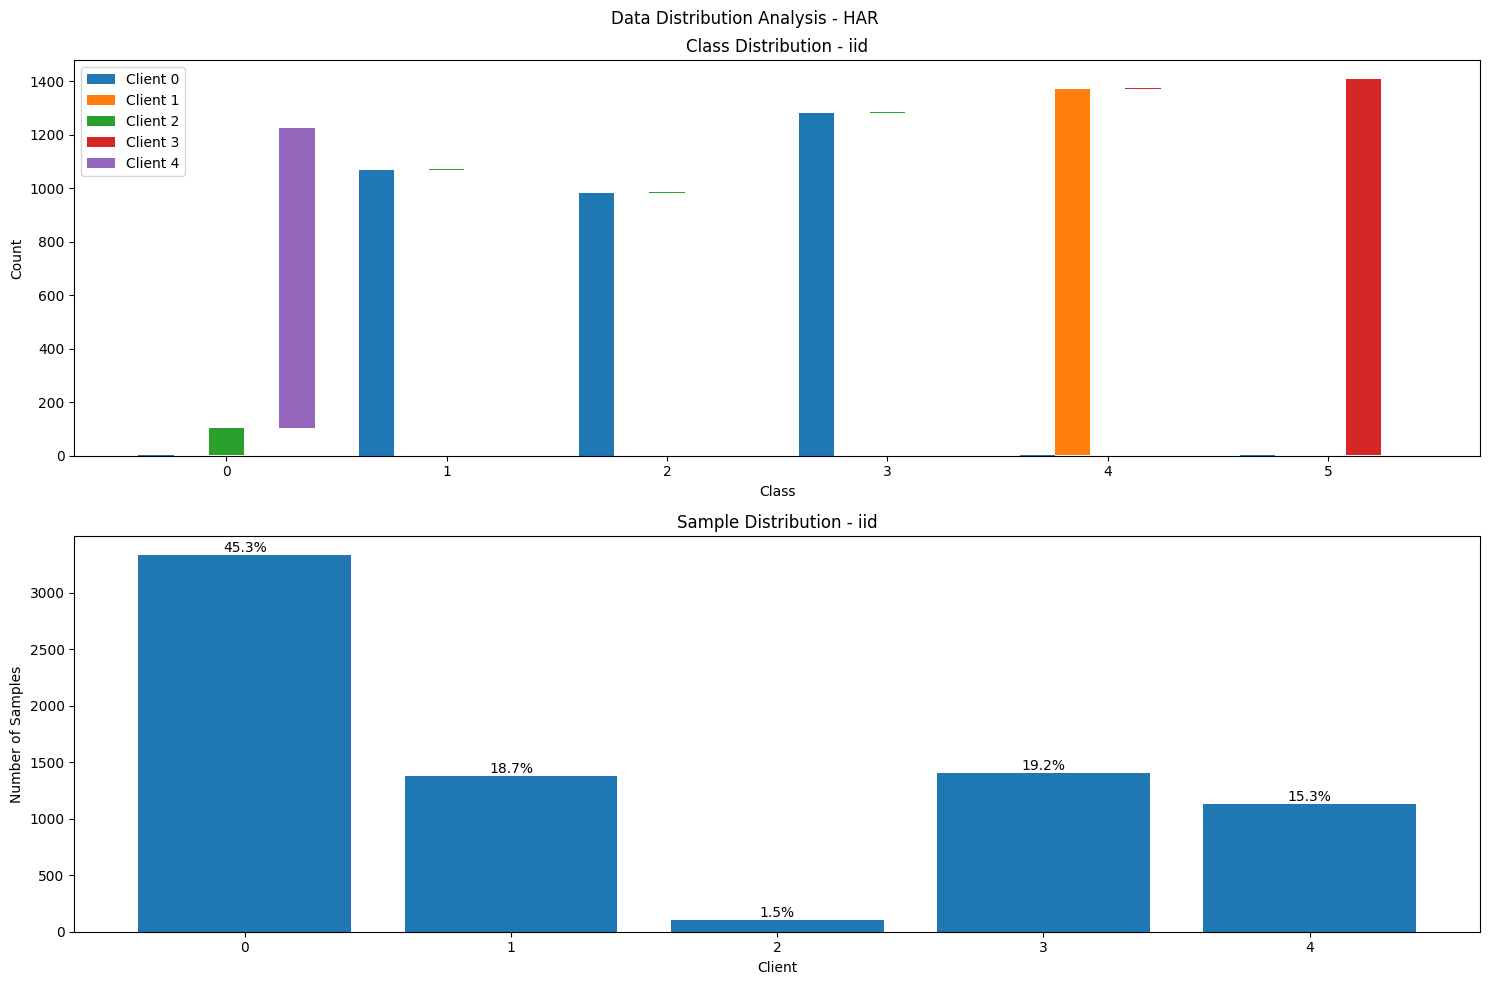

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "HAR")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "HAR")
plt.show()

In [7]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("har")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x00000277C667B1D0>
optimizer: {'type': 'sgd', 'lr': 0.001, 'momentum': 0.9, 'weight_decay': 0.0001, 'nesterov': True}
lr_scheduler: {'type': 'cosine', 'T_max': 50, 'eta_min': 1e-05, 'warmup_epochs': 3, 'warmup_start_lr': 1e-05}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
quantization: {'bits': 8, 'enabled': True, 'adaptive': True, 'min_bits': 4, 'max_bits': 16, 'layer_specific': True, 'error_threshold': 0.01, 'momentum': 0.9}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 5


In [8]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Get base config
    config = get_tinyprop_config('har')
    
    # Run training
    model, metrics = federated_training(
        client_datasets=client_datasets,
        model_name='har',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/har_metrics.csv',  # Single CSV file for all partitions
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        save_dir='results',
        save_interval=1,
        use_dense_baseline=True
    )
    
    # Print summary statistics
    print(f"\nTraining Summary for {partition_name.upper()}:")
    print(f"Final Accuracy: {metrics['accuracy'][-1]:.4f}")
    print(f"Average Sparsity: {np.mean(metrics['sparsity']):.4f}")
    print(f"Average Compression Ratio: {np.mean(metrics['compression_ratio']):.4f}")
    print(f"Average Effective Compute Ratio: {np.mean(metrics['effective_compute_ratio']):.4f}")
    print(f"Total Communication Cost: {metrics['communication'][-1]/1024:.2f} KB")
    print(f"Total Memory Saved: {metrics['memory_saved'][-1]:.2f} MB")
    
    return model, metrics

# Run training for each partition
partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, metrics = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'metrics': metrics
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue


Starting training for IID partition...

Training on partition: IID

[Training Debug] Initializing clients...
[Training Debug] Client 0 initialized with 3333 samples
[Training Debug] Client 1 initialized with 1375 samples
[Training Debug] Client 2 initialized with 108 samples
[Training Debug] Client 3 initialized with 1408 samples
[Training Debug] Client 4 initialized with 1128 samples

Round 1/100

[Training Debug] Training client 0

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 1

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 2

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 3

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Training Debug] Training client 